In [1]:
%pip install qiskit qiskit-aer qiskit-machine-learning qiskit-algorithms

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Qiskit imports
from qiskit import transpile
from qiskit.circuit.library import ZZFeatureMap
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit_machine_learning.kernels import TrainableFidelityQuantumKernel
from qiskit_algorithms.state_fidelities import ComputeUncompute

# finding the EMBER .jsonl files live
DATA_DIR = "/Users/theaurilios/srp/EMBER2024/EMBER24_Data/"
MAX_SAMPLES = 20000

jsonl_files = [
    os.path.join(DATA_DIR, f) 
    for f in os.listdir(DATA_DIR) 
    if f.endswith('.jsonl')
]

print(f"Found {len(jsonl_files)} JSONL file(s) in directory.")

records = []
for file_path in jsonl_files:
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if len(records) >= MAX_SAMPLES:
                break
            
            data = json.loads(line)
            label = data.get('label', None)
            
            #  ember uses -1 for unlabeled data
            if label is None or label == -1:
                continue
            
            # Extracting the 10 features
            gen = data.get('general', {})
            records.append({
                'size': gen.get('size', 0),
                'has_debug': gen.get('has_debug', 0),
                'has_exports': gen.get('has_exports', 0),
                'has_imports': gen.get('has_imports', 0),
                'has_relocations': gen.get('has_relocations', 0),
                'has_resources': gen.get('has_resources', 0),
                'has_signature': gen.get('has_signature', 0),
                'has_tls': gen.get('has_tls', 0),
                'symbols_in_export': gen.get('symbols_in_export', 0),
                'symbols_in_import': gen.get('symbols_in_import', 0),
                'label': label
            })
            
    if len(records) >= MAX_SAMPLES:
        break

df = pd.DataFrame(records)
print(f"Loaded {len(df)} samples into DataFrame.")
df.info()

Found 72 JSONL file(s) in directory.
Loaded 20000 samples into DataFrame.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   size               20000 non-null  int64
 1   has_debug          20000 non-null  int64
 2   has_exports        20000 non-null  int64
 3   has_imports        20000 non-null  int64
 4   has_relocations    20000 non-null  int64
 5   has_resources      20000 non-null  int64
 6   has_signature      20000 non-null  int64
 7   has_tls            20000 non-null  int64
 8   symbols_in_export  20000 non-null  int64
 9   symbols_in_import  20000 non-null  int64
 10  label              20000 non-null  int64
dtypes: int64(11)
memory usage: 1.7 MB


In [3]:
# EMBER's 10 overlapping features
ember_features = [
    'size', 'has_debug', 'has_exports', 'has_imports', 'has_relocations',
    'has_resources', 'has_signature', 'has_tls', 'symbols_in_export', 'symbols_in_import'
]

# Separate features (x) and target labels (y)
x = df[ember_features]

# Automatically detect label column name
label_col = 'label' if 'label' in df.columns else 'class'
y = df[label_col]

print(f"x shape: {x.shape}")
print(f"y shape: {y.shape}")

x shape: (20000, 10)
y shape: (20000,)


In [4]:
#  80/20 train/test split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=10, stratify=y
)

print(f"Training samples: {len(x_train)}")
print(f"Testing samples:  {len(x_test)}")

Training samples: 16000
Testing samples:  4000


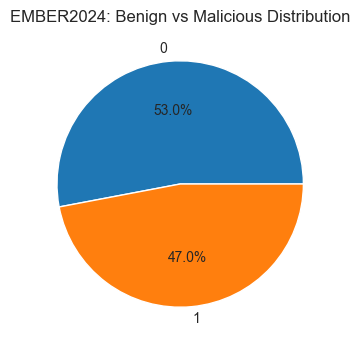

In [5]:
sns.set_style('whitegrid') 
plt.figure(figsize=(6, 4)) 

label_col = 'label' if 'label' in df.columns else 'class'
plt.pie(
    df[label_col].value_counts(), 
    labels=df[label_col].value_counts().index, 
    autopct='%1.1f%%'
)
plt.title('EMBER2024: Benign vs Malicious Distribution')
plt.show()

In [6]:

scaler = MinMaxScaler(feature_range=(0, 1))

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Min: {x_train_scaled.min():.1f}, Max: {x_train_scaled.max():.1f}")

Min: 0.0, Max: 1.0


In [7]:
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# The 10 features reduced down to 6 features so it will run on laptop. Uses PCA
n_components = 10
pca = PCA(n_components=n_components, random_state=42)

x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print(f"Explained Variance Ratio by {n_components} PCA components: {sum(pca.explained_variance_ratio_):.2f}")

# downsampling for quantum simulator speed and no crashing
subset_train_size = 200
subset_test_size = 50

qX_train, _, qy_train, _ = train_test_split(
    x_train_pca, y_train, train_size=subset_train_size, stratify=y_train, random_state=42
)

qX_test, _, qy_test, _ = train_test_split(
    x_test_pca, y_test, train_size=subset_test_size, stratify=y_test, random_state=42
)

print(f"Train Shape: {qX_train.shape}, Test Shape: {qX_test.shape}")

Explained Variance Ratio by 10 PCA components: 1.00
Train Shape: (200, 10), Test Shape: (50, 10)


In [8]:
num_features = qX_train.shape[1]

# FeatureMap
raw_feature_map = ZZFeatureMap(feature_dimension=num_features, reps=2, entanglement='linear')

# Draw the circuit
print(raw_feature_map.decompose().draw(output='text'))

# Decompose into standard gates for Aer
feature_map = raw_feature_map.decompose()

     ┌───┐┌─────────────┐                                          ┌───┐»
q_0: ┤ H ├┤ P(2.0*x[0]) ├──■────────────────────────────────────■──┤ H ├»
     ├───┤├─────────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐└───┘»
q_1: ┤ H ├┤ P(2.0*x[1]) ├┤ X ├┤ P(2.0*(π - x[0])*(π - x[1])) ├┤ X ├──■──»
     ├───┤├─────────────┤└───┘└──────────────────────────────┘└───┘┌─┴─┐»
q_2: ┤ H ├┤ P(2.0*x[2]) ├──────────────────────────────────────────┤ X ├»
     ├───┤├─────────────┤                                          └───┘»
q_3: ┤ H ├┤ P(2.0*x[3]) ├───────────────────────────────────────────────»
     ├───┤├─────────────┤                                               »
q_4: ┤ H ├┤ P(2.0*x[4]) ├───────────────────────────────────────────────»
     ├───┤├─────────────┤                                               »
q_5: ┤ H ├┤ P(2.0*x[5]) ├───────────────────────────────────────────────»
     ├───┤├─────────────┤                                               »
q_6: ┤ H ├┤ P(2.0*x[6]) ├─────────────

In [9]:
# Aer Backend and Sampler
backend = AerSimulator()
sampler = AerSampler()

# State fidelity and qkernel for no running errors
fidelity = ComputeUncompute(sampler=sampler)
qkernel = TrainableFidelityQuantumKernel(fidelity=fidelity, feature_map=feature_map)

# Train the SVM using the Quantum Kernel
qsvm = SVC(kernel=qkernel.evaluate, class_weight='balanced', C=1.0) #class balancing 
qsvm.fit(qX_train, qy_train)

SVC(class_weight='balanced',
    kernel=<bound method FidelityQuantumKernel.evaluate of <qiskit_machine_learning.kernels.trainable_fidelity_quantum_kernel.TrainableFidelityQuantumKernel object at 0x12c98fd90>>)

In [10]:
# Results
q_predictions = qsvm.predict(qX_test)
q_scores = qsvm.decision_function(qX_test)

print("Quantum Overall Accuracy:", accuracy_score(qy_test, q_predictions))
print("\nClassification Report:\n", classification_report(qy_test, q_predictions))

Quantum Overall Accuracy: 0.54

Classification Report:
               precision    recall  f1-score   support

           0       0.53      1.00      0.69        26
           1       1.00      0.04      0.08        24

    accuracy                           0.54        50
   macro avg       0.77      0.52      0.39        50
weighted avg       0.76      0.54      0.40        50

